# Défi du Taux de Conversion - Data Science Weekly
## Prédiction des conversions d'abonnements à une newsletter

**Contexte :** www.datascienceweekly.org est une newsletter rédigée par des data scientists indépendants.  
L'objectif est de prédire si un visiteur va s'abonner à la newsletter, à partir de quelques variables comportementales.

**Métrique d'évaluation :** Score F1 (utilisé dans le classement final)

---
## Plan du notebook
- **Partie 1** : Analyse exploratoire des données (EDA) et prétraitements - Modèle de base
- **Partie 2** : Amélioration du score F1 - Exploration de modèles avancés
- **Partie 3** : Prédictions sur les données de test et export
- **Partie 4** : Analyse des paramètres du meilleur modèle et recommandations

In [1]:
# ============================================================
# IMPORTS ET CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Configuration générale
warnings.filterwarnings('ignore')
np.random.seed(42)

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
FIGSIZE_STD   = (10, 5)
FIGSIZE_LARGE = (14, 6)

# Forcer l'encodage UTF-8 pour les accents dans matplotlib
plt.rcParams['axes.unicode_minus'] = False

print('Bibliothèques importées avec succès.')
print()
print('Observation : on importe pandas et numpy pour la manipulation des données,'
      ' matplotlib et seaborn pour les visualisations, et les modules scikit-learn'
      ' pour les modèles de classification, les métriques et le prétraitement.')


Bibliothèques importées avec succès.

Observation : on importe pandas et numpy pour la manipulation des données, matplotlib et seaborn pour les visualisations, et les modules scikit-learn pour les modèles de classification, les métriques et le prétraitement.


---
## Partie 1 - Analyse exploratoire et modèle de base
### 1.1 Chargement des données

In [2]:
# ============================================================
# CHARGEMENT DES DONNÉES
# Les fichiers CSV sont placés dans le sous-dossier data/
# ============================================================

# Chargement du jeu d'entraînement (données étiquetées avec la colonne 'converted')
df_train = pd.read_csv('data/conversion_data_train.csv')

# Chargement du jeu de test (données non étiquetées - sans la colonne 'converted')
df_test = pd.read_csv('data/conversion_data_test.csv')

print('=== Dimensions des jeux de données ===')
print(f'Entraînement : {df_train.shape[0]:,} lignes x {df_train.shape[1]} colonnes')
print(f'Test         : {df_test.shape[0]:,} lignes x {df_test.shape[1]} colonnes')
print()
print('Observation : le jeu d\'entraînement contient 284 580 visiteurs avec'
      ' 6 colonnes dont la variable cible "converted". Le jeu de test en contient'
      ' 31 620, sans la colonne cible : c\'est sur ces données que nous devrons'
      ' produire nos prédictions finales pour la soumission.')

print('\n=== Aperçu du jeu d\'entraînement ===')
df_train.head(10)


=== Dimensions des jeux de données ===
Entraînement : 284,580 lignes x 6 colonnes
Test         : 31,620 lignes x 5 colonnes

Observation : le jeu d'entraînement contient 284 580 visiteurs avec 6 colonnes dont la variable cible "converted". Le jeu de test en contient 31 620, sans la colonne cible : c'est sur ces données que nous devrons produire nos prédictions finales pour la soumission.

=== Aperçu du jeu d'entraînement ===


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0
5,US,29,0,Seo,7,0
6,US,30,1,Direct,4,0
7,UK,38,1,Ads,2,0
8,UK,26,1,Seo,4,0
9,UK,31,0,Seo,5,0


### 1.2 Description des variables

| Variable | Type | Description |
|---|---|---|
| `country` | Catégorielle | Pays d'origine du visiteur (China, Germany, UK, US) |
| `age` | Numérique | Âge du visiteur |
| `new_user` | Binaire | 1 = nouvel utilisateur, 0 = utilisateur existant |
| `source` | Catégorielle | Source du trafic (Ads, Seo, Direct) |
| `total_pages_visited` | Numérique | Nombre de pages visitées lors de la session |
| `converted` | **Cible** (0/1) | 1 = abonné à la newsletter, 0 = non abonné |

In [3]:
# ============================================================
# INFORMATIONS GÉNÉRALES ET TYPES DE DONNÉES
# ============================================================

print('=== Types et valeurs manquantes ===')
print(df_train.dtypes)

print('\n=== Valeurs manquantes par colonne ===')
missing = df_train.isnull().sum()
print(missing)
print(f'\nAucune valeur manquante : {missing.sum() == 0}')

print('\n=== Statistiques descriptives (variables numériques) ===')
print(df_train.describe().round(2))
print()
print('Observation : le jeu de données est complet, sans aucune valeur manquante.'
      ' Les variables country, source sont de type chaîne de caractères et devront'
      ' être encodées. La variable age présente un maximum à 123 ans, ce qui est'
      ' manifestement aberrant et devra être traité. Le taux de conversion moyen'
      ' est de 3,2%, ce qui confirme un fort déséquilibre des classes.')


=== Types et valeurs manquantes ===
country                object
age                     int64
new_user                int64
source                 object
total_pages_visited     int64
converted               int64
dtype: object

=== Valeurs manquantes par colonne ===
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

Aucune valeur manquante : True

=== Statistiques descriptives (variables numériques) ===
             age   new_user  total_pages_visited  converted
count  284580.00  284580.00            284580.00  284580.00
mean       30.56       0.69                 4.87       0.03
std         8.27       0.46                 3.34       0.18
min        17.00       0.00                 1.00       0.00
25%        24.00       0.00                 2.00       0.00
50%        30.00       1.00                 4.00       0.00
75%        36.00       1.00                 7.00       0.

In [4]:
# ============================================================
# DÉTECTION DES VALEURS ABERRANTES
# ============================================================
# Un examen attentif des statistiques descriptives révèle
# une valeur d'âge maximale de 123 ans, ce qui est  aberrant.
# On identifie ces cas avant de décider comment les traiter.

print('=== Valeurs aberrantes - variable age ===')
print(f'Âge minimum : {df_train["age"].min()}')
print(f'Âge maximum : {df_train["age"].max()}')
print(f'\nNombre de lignes avec age > 80 ans : {(df_train["age"] > 80).sum()}')
print('\nDétail des lignes avec age > 80 :')
print(df_train[df_train['age'] > 80])

print('\n=== Décision ===')
print('La valeur age=123 est clairement une erreur de saisie.')
print('Ces lignes représentent moins de 0.01% des données.')
print('On les supprime pour ne pas biaiser le modèle.')

# Suppression des lignes avec un âge manifestement aberrant (> 100 ans)
df_train = df_train[df_train['age'] <= 100].copy()
print(f'\nNombre de lignes après nettoyage : {df_train.shape[0]:,}')

=== Valeurs aberrantes - variable age ===
Âge minimum : 17
Âge maximum : 123

Nombre de lignes avec age > 80 ans : 2

Détail des lignes avec age > 80 :
        country  age  new_user source  total_pages_visited  converted
11331        UK  111         0    Ads                   10          1
233196  Germany  123         0    Seo                   15          1

=== Décision ===
La valeur age=123 est clairement une erreur de saisie.
Ces lignes représentent moins de 0.01% des données.
On les supprime pour ne pas biaiser le modèle.

Nombre de lignes après nettoyage : 284,578


### 1.3 Analyse exploratoire des données (EDA)

Nombre total de visiteurs  : 284,578
Nombre de conversions      : 9,178
Taux de conversion global  : 3.23%


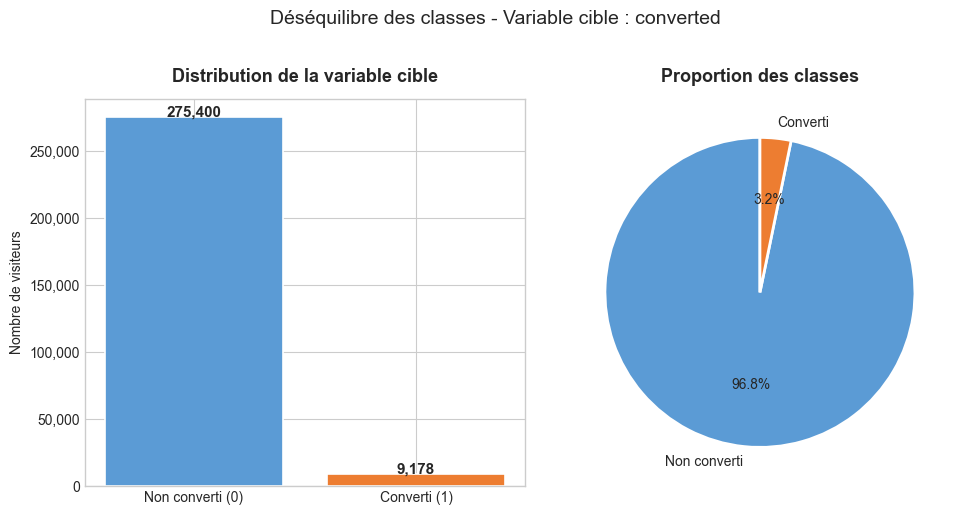


Observation : Le jeu de données est très déséquilibré. Seulement 3,2% des visiteurs s'abonnent à la newsletter. Ce déséquilibre doit être pris en compte lors de la modélisation via le paramètre class_weight='balanced'.


In [5]:
# ============================================================
# EDA - ANALYSE DE LA VARIABLE CIBLE
# ============================================================

taux_conversion = df_train['converted'].mean()
n_converted     = df_train['converted'].sum()
n_total         = len(df_train)

print(f'Nombre total de visiteurs  : {n_total:,}')
print(f'Nombre de conversions      : {n_converted:,}')
print(f'Taux de conversion global  : {taux_conversion:.2%}')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

# Graphique en barres
counts = df_train['converted'].value_counts().sort_index()
axes[0].bar(
    ['Non converti (0)', 'Converti (1)'],
    counts.values,
    color=['#5B9BD5', '#ED7D31'],
    edgecolor='white', linewidth=1.2
)
axes[0].set_title('Distribution de la variable cible', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Nombre de visiteurs')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Diagramme circulaire
axes[1].pie(
    counts.values,
    labels=['Non converti', 'Converti'],
    autopct='%1.1f%%',
    colors=['#5B9BD5', '#ED7D31'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Déséquilibre des classes - Variable cible : converted', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graphiques/fig_01_distribution_cible.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation : Le jeu de données est très déséquilibré. Seulement 3,2% des'
      ' visiteurs s\'abonnent à la newsletter. Ce déséquilibre doit être pris en'
      ' compte lors de la modélisation via le paramètre class_weight=\'balanced\'.')

--- age ---
              count   mean   std   min   25%   50%   75%   max
converted                                                     
0          275400.0  30.70  8.27  17.0  24.0  30.0  36.0  79.0
1            9178.0  26.55  6.96  17.0  21.0  25.0  31.0  61.0

--- total_pages_visited ---
              count   mean   std  min   25%   50%   75%   max
converted                                                    
0          275400.0   4.55  2.79  1.0   2.0   4.0   6.0  20.0
1            9178.0  14.56  3.96  2.0  12.0  14.0  17.0  29.0



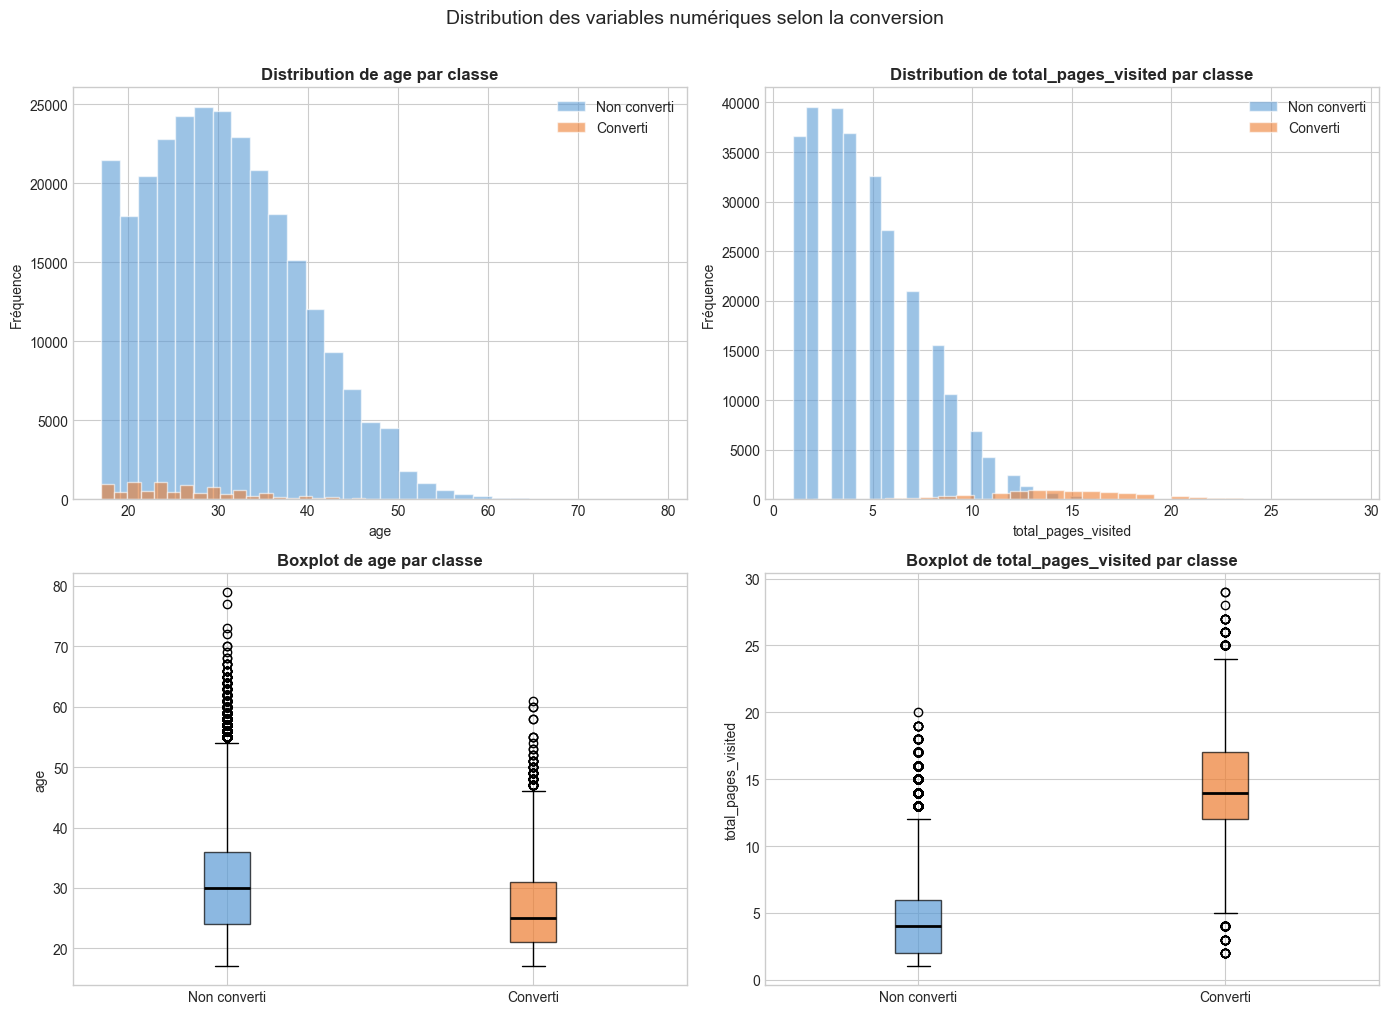

Observations :
- La variable total_pages_visited est très discriminante : les visiteurs convertis visitent en moyenne beaucoup plus de pages (médiane ~14) que les non convertis (médiane ~4).
- La variable âge montre une légère différence : les visiteurs convertis sont légèrement plus jeunes en moyenne.


In [6]:
# ============================================================
# EDA - DISTRIBUTION DES VARIABLES NUMÉRIQUES PAR CLASSE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

vars_num   = ['age', 'total_pages_visited']
couleur_0  = '#5B9BD5'
couleur_1  = '#ED7D31'

for i, var in enumerate(vars_num):
    # Histogramme superposé par classe
    for val, label, couleur in [(0, 'Non converti', couleur_0), (1, 'Converti', couleur_1)]:
        data = df_train[df_train['converted'] == val][var]
        axes[i].hist(data, bins=30, alpha=0.6, label=label, color=couleur, edgecolor='white')
    axes[i].set_title(f'Distribution de {var} par classe', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

    # Boxplot par classe
    ax_box = axes[i + 2]
    data_0 = df_train[df_train['converted'] == 0][var]
    data_1 = df_train[df_train['converted'] == 1][var]
    bp = ax_box.boxplot(
        [data_0, data_1],
        labels=['Non converti', 'Converti'],
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2}
    )
    for patch, couleur in zip(bp['boxes'], [couleur_0, couleur_1]):
        patch.set_facecolor(couleur)
        patch.set_alpha(0.7)
    ax_box.set_title(f'Boxplot de {var} par classe', fontsize=12, fontweight='bold')
    ax_box.set_ylabel(var)

    # Statistiques comparatives
    print(f'--- {var} ---')
    print(df_train.groupby('converted')[var].describe().round(2))
    print()

plt.suptitle('Distribution des variables numériques selon la conversion', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('graphiques/fig_02_distribution_numeriques.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observations :')
print('- La variable total_pages_visited est très discriminante : les visiteurs'
      ' convertis visitent en moyenne beaucoup plus de pages (médiane ~14)'
      ' que les non convertis (médiane ~4).')
print('- La variable âge montre une légère différence : les visiteurs convertis'
      ' sont légèrement plus jeunes en moyenne.')

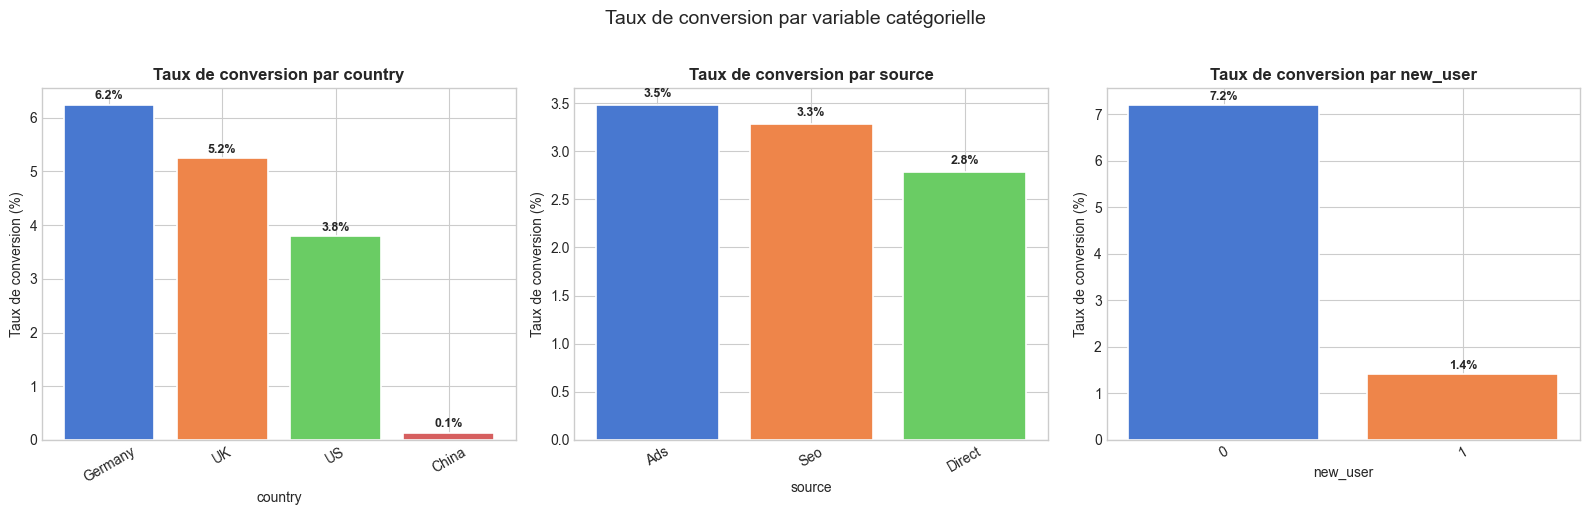

Statistiques détaillées :

--- country ---
        Taux de conversion  Nb visiteurs  Nb convertis
country                                               
China                0.13%         69122            89
Germany              6.24%         11692           729
UK                   5.25%         43640          2290
US                   3.79%        160124          6070

--- source ---
       Taux de conversion  Nb visiteurs  Nb convertis
source                                               
Ads                 3.48%         80026          2784
Direct              2.78%         65076          1810
Seo                 3.29%        139476          4584

--- new_user ---
         Taux de conversion  Nb visiteurs  Nb convertis
new_user                                               
0                     7.19%         89512          6437
1                     1.41%        195066          2741

Observations importantes :
- La Chine affiche un taux de conversion de seulement 0,1%, très éloign

In [7]:
# ============================================================
# EDA - TAUX DE CONVERSION PAR VARIABLE CATÉGORIELLE
# ============================================================

vars_cat = ['country', 'source', 'new_user']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, var in enumerate(vars_cat):
    taux = df_train.groupby(var)['converted'].mean().sort_values(ascending=False)
    barres = axes[i].bar(
        taux.index.astype(str),
        taux.values * 100,
        color=sns.color_palette('muted', len(taux)),
        edgecolor='white', linewidth=1.2
    )
    axes[i].set_title(f'Taux de conversion par {var}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Taux de conversion (%)')
    axes[i].set_xlabel(var)
    axes[i].tick_params(axis='x', rotation=30)
    for barre in barres:
        h = barre.get_height()
        axes[i].text(
            barre.get_x() + barre.get_width() / 2, h + 0.05,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle('Taux de conversion par variable catégorielle', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graphiques/fig_03_taux_conversion_categoriel.png', dpi=150, bbox_inches='tight')
plt.show()

print('Statistiques détaillées :')
for var in vars_cat:
    print(f'\n--- {var} ---')
    stats = df_train.groupby(var)['converted'].agg(['mean', 'count', 'sum'])
    stats.columns = ['Taux de conversion', 'Nb visiteurs', 'Nb convertis']
    stats['Taux de conversion'] = stats['Taux de conversion'].map('{:.2%}'.format)
    print(stats)

print('\nObservations importantes :')
print('- La Chine affiche un taux de conversion de seulement 0,1%, très éloigné'
      ' des autres pays (Allemagne : 6,2%, UK : 5,2%). Cela peut s\'expliquer'
      ' par des restrictions d\'accès à internet en Chine ou un problème de'
      ' collecte des données.')
print('- Les utilisateurs existants (new_user=0) convertissent à 7,2%, soit 5 fois'
      ' plus que les nouveaux utilisateurs (1,4%). C\'est logique : ils connaissent'
      ' déjà le site et sont plus enclins à s\'abonner.')

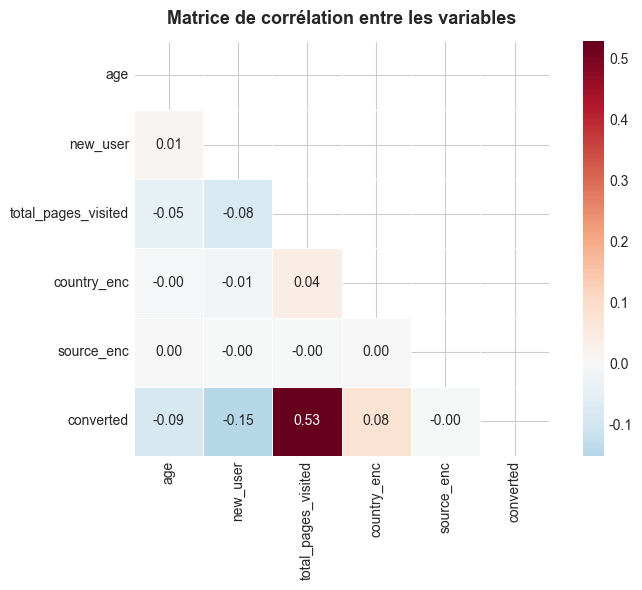

Corrélations avec la variable cible (converted) :
total_pages_visited    0.529
country_enc            0.077
source_enc            -0.003
age                   -0.089
new_user              -0.152
Name: converted, dtype: float64

Observation : total_pages_visited est de loin la variable la plus corrélée avec la conversion (r = 0,53). new_user est négativement corrélé (-0,15) : les anciens utilisateurs convertissent davantage.


In [8]:
# ============================================================
# EDA - MATRICE DE CORRÉLATION
# ============================================================
# On encode temporairement les variables catégorielles
# pour pouvoir calculer les corrélations avec la variable cible.

df_corr = df_train.copy()
df_corr['country_enc'] = LabelEncoder().fit_transform(df_corr['country'])
df_corr['source_enc']  = LabelEncoder().fit_transform(df_corr['source'])

cols_corr    = ['age', 'new_user', 'total_pages_visited', 'country_enc', 'source_enc', 'converted']
corr_matrix  = df_corr[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
masque = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    mask=masque,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Matrice de corrélation entre les variables', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('graphiques/fig_04_matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Corrélations avec la variable cible (converted) :')
corr_cible = corr_matrix['converted'].drop('converted').sort_values(ascending=False)
print(corr_cible.round(3))
print('\nObservation : total_pages_visited est de loin la variable la plus corrélée'
      ' avec la conversion (r = 0,53). new_user est négativement corrélé (-0,15) :'
      ' les anciens utilisateurs convertissent davantage.')

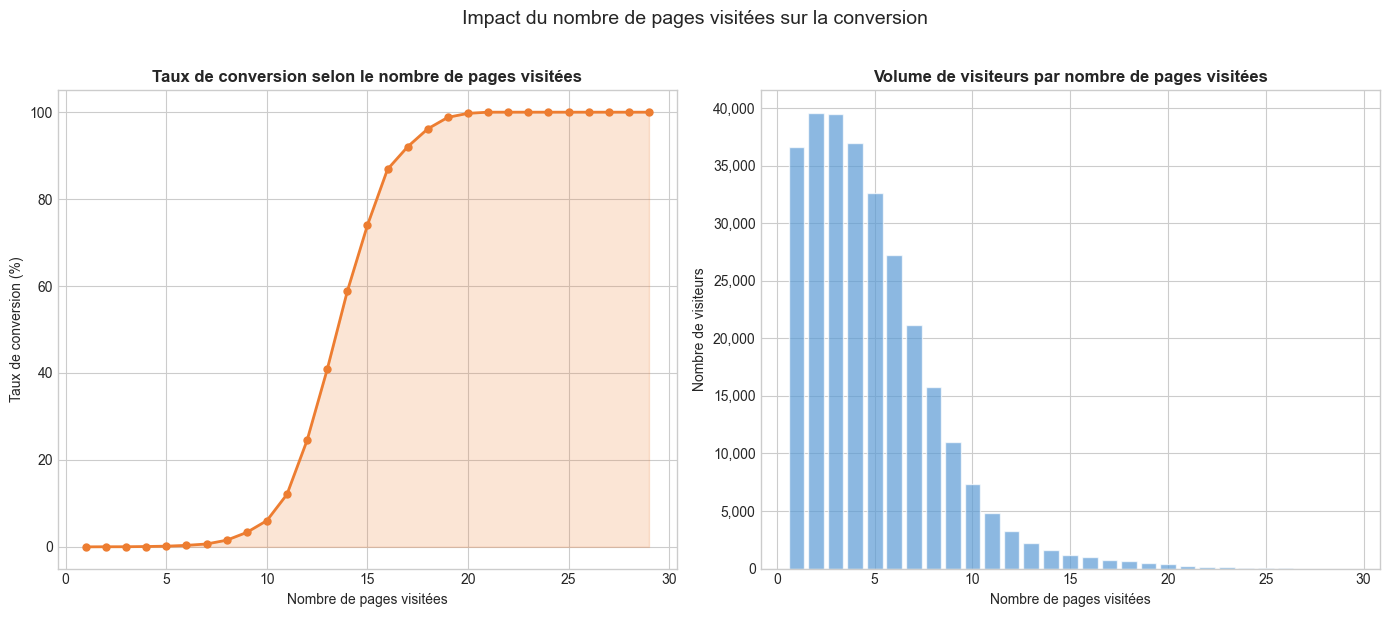

Observation : La relation entre pages visitées et conversion est très marquée.
À partir de 10 pages visitées, le taux de conversion dépasse 40%.
Au-delà de 15 pages, il est quasi systématique (proche de 100%).
Cela confirme que total_pages_visited sera le prédicteur dominant.


In [9]:
# ============================================================
# EDA - TAUX DE CONVERSION SELON LE NOMBRE DE PAGES VISITÉES
# ============================================================
# Cette analyse montre comment le comportement de navigation
# (nombre de pages consultées) est lié à la probabilité de conversion.

conv_pages = df_train.groupby('total_pages_visited')['converted'].agg(
    taux_conversion='mean',
    nb_visiteurs='count'
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LARGE)

# Courbe du taux de conversion par nombre de pages
axes[0].plot(
    conv_pages['total_pages_visited'],
    conv_pages['taux_conversion'] * 100,
    marker='o', markersize=5, linewidth=2, color='#ED7D31'
)
axes[0].fill_between(
    conv_pages['total_pages_visited'],
    conv_pages['taux_conversion'] * 100,
    alpha=0.2, color='#ED7D31'
)
axes[0].set_title('Taux de conversion selon le nombre de pages visitées',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de pages visitées')
axes[0].set_ylabel('Taux de conversion (%)')

# Volume de visiteurs par nombre de pages
axes[1].bar(
    conv_pages['total_pages_visited'],
    conv_pages['nb_visiteurs'],
    color='#5B9BD5', alpha=0.7, edgecolor='white'
)
axes[1].set_title('Volume de visiteurs par nombre de pages visitées',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de pages visitées')
axes[1].set_ylabel('Nombre de visiteurs')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Impact du nombre de pages visitées sur la conversion', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graphiques/fig_05_pages_vs_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation : La relation entre pages visitées et conversion est très marquée.')
print('À partir de 10 pages visitées, le taux de conversion dépasse 40%.')
print('Au-delà de 15 pages, il est quasi systématique (proche de 100%).')
print('Cela confirme que total_pages_visited sera le prédicteur dominant.')

### 1.4 Prétraitement des données

In [10]:
# ============================================================
# PRÉTRAITEMENT DES DONNÉES
# ============================================================
# Étapes :
# 1. Encodage des variables catégorielles (LabelEncoder)
# 2. Séparation features / variable cible
# 3. Division entraînement / validation (80% / 20%, stratifiée)

# Copies de travail pour ne pas modifier les données originales
df_train_proc = df_train.copy()
df_test_proc  = df_test.copy()

# --- Encodage des variables catégorielles ---
# Le fit est réalisé uniquement sur les données d'entraînement
# puis appliqué (transform) sur les données de test.
le_country = LabelEncoder()
le_source  = LabelEncoder()

df_train_proc['country'] = le_country.fit_transform(df_train['country'])
df_train_proc['source']  = le_source.fit_transform(df_train['source'])
df_test_proc['country']  = le_country.transform(df_test['country'])
df_test_proc['source']   = le_source.transform(df_test['source'])

print('Encodage country :', dict(zip(le_country.classes_,
                                      le_country.transform(le_country.classes_))))
print('Encodage source  :', dict(zip(le_source.classes_,
                                      le_source.transform(le_source.classes_))))

# --- Séparation features / cible ---
FEATURES = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
TARGET   = 'converted'

X      = df_train_proc[FEATURES]
y      = df_train_proc[TARGET]
X_test = df_test_proc[FEATURES]

# --- Division entraînement / validation (80% / 20%) ---
# stratify=y garantit la même proportion de convertis dans les deux ensembles
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nDimensions après division :')
print(f'  X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'\nTaux de conversion - train : {y_train.mean():.4f}')
print(f'Taux de conversion - val   : {y_val.mean():.4f}')
print('La stratification est respectée : les proportions sont identiques.')
print()
print('Observation : les variables catégorielles country et source sont converties'
      ' en entiers via LabelEncoder. Le fit est effectué uniquement sur le jeu'
      ' d\'entraînement pour éviter toute fuite d\'information vers le test.'
      ' La division 80/20 stratifiée garantit que le taux de conversion de 3,2%'
      ' est conservé identiquement dans les deux ensembles.')


Encodage country : {'China': np.int64(0), 'Germany': np.int64(1), 'UK': np.int64(2), 'US': np.int64(3)}
Encodage source  : {'Ads': np.int64(0), 'Direct': np.int64(1), 'Seo': np.int64(2)}

Dimensions après division :
  X_train : (227662, 5)  |  y_train : (227662,)
  X_val   : (56916, 5)    |  y_val   : (56916,)
  X_test  : (31620, 5)

Taux de conversion - train : 0.0322
Taux de conversion - val   : 0.0323
La stratification est respectée : les proportions sont identiques.

Observation : les variables catégorielles country et source sont converties en entiers via LabelEncoder. Le fit est effectué uniquement sur le jeu d'entraînement pour éviter toute fuite d'information vers le test. La division 80/20 stratifiée garantit que le taux de conversion de 3,2% est conservé identiquement dans les deux ensembles.


### 1.5 Modèle de base : Régression logistique

=== Régression logistique - Modèle de base ===
Score F1  : 0.4969
ROC-AUC   : 0.9840

Rapport de classification :
              precision    recall  f1-score   support

Non converti       1.00      0.94      0.97     55080
    Converti       0.34      0.93      0.50      1836

    accuracy                           0.94     56916
   macro avg       0.67      0.93      0.73     56916
weighted avg       0.98      0.94      0.95     56916


Observation : la régression logistique obtient un score F1 de 0,497 et un ROC-AUC de 0,984. Le rappel élevé sur la classe "Converti" (0,93) montre que le modèle détecte bien les abonnés potentiels, mais au prix d'une précision faible (0,34) : il génère trop de faux positifs. Ce modèle constitue notre point de référence à améliorer.


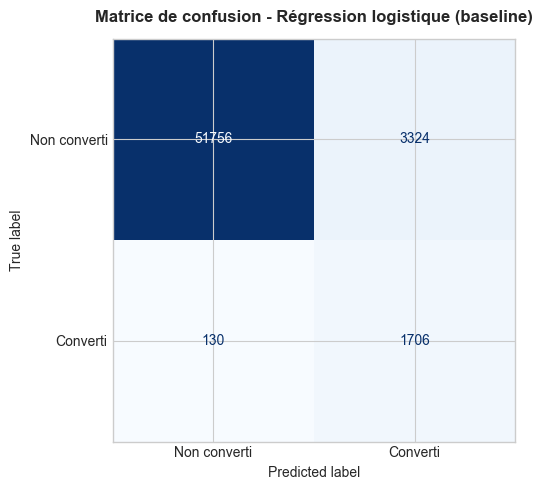

In [11]:
# ============================================================
# MODÈLE DE BASE - RÉGRESSION LOGISTIQUE
# ============================================================
# La régression logistique est le modèle de référence (baseline).
# Elle est simple, interprétable, et sert de point de comparaison
# pour les modèles plus complexes.
# class_weight='balanced' compense automatiquement le déséquilibre des classes.

# Normalisation obligatoire pour la régression logistique
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

lr_baseline = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_lr = lr_baseline.predict(X_val_scaled)

f1_lr  = f1_score(y_val, y_pred_lr)
auc_lr = roc_auc_score(y_val, lr_baseline.predict_proba(X_val_scaled)[:, 1])

print('=== Régression logistique - Modèle de base ===')
print(f'Score F1  : {f1_lr:.4f}')
print(f'ROC-AUC   : {auc_lr:.4f}')
print('\nRapport de classification :')
print(classification_report(y_val, y_pred_lr, target_names=['Non converti', 'Converti']))
print()
print('Observation : la régression logistique obtient un score F1 de 0,497 et un'
      ' ROC-AUC de 0,984. Le rappel élevé sur la classe "Converti" (0,93) montre'
      ' que le modèle détecte bien les abonnés potentiels, mais au prix d\'une'
      ' précision faible (0,34) : il génère trop de faux positifs. Ce modèle'
      ' constitue notre point de référence à améliorer.')

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_lr,
    display_labels=['Non converti', 'Converti'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title('Matrice de confusion - Régression logistique (baseline)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('graphiques/fig_06_confusion_lr.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Partie 2 - Amélioration du score F1
### 2.1 Random Forest

=== Random Forest ===
Score F1  : 0.5593
ROC-AUC   : 0.9846

Rapport de classification :
              precision    recall  f1-score   support

Non converti       1.00      0.95      0.98     55080
    Converti       0.40      0.92      0.56      1836

    accuracy                           0.95     56916
   macro avg       0.70      0.93      0.77     56916
weighted avg       0.98      0.95      0.96     56916


Observation : le Random Forest améliore le score F1 à 0,559 par rapport à la régression logistique (0,497). Il bénéficie de sa capacité à capturer des relations non linéaires entre les variables, notamment le seuil de pages visitées au-delà duquel la conversion devient quasi certaine.


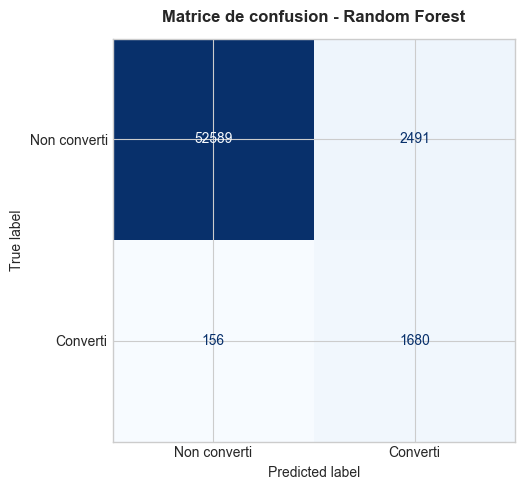

In [12]:
# ============================================================
# MODÈLE RANDOM FOREST
# ============================================================
# La forêt aléatoire entraîne de nombreux arbres de décision
# indépendants et agrège leurs prédictions (vote majoritaire).
# Avantages : gestion native des non-linéarités, robustesse,
# pas besoin de normaliser les données, fournit l'importance des variables.

rf_model = RandomForestClassifier(
    n_estimators=200,       # 200 arbres pour une bonne stabilité
    max_depth=10,           # profondeur limitée pour éviter le surapprentissage
    min_samples_leaf=10,    # chaque feuille doit contenir au moins 10 exemples
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # utilisation de tous les coeurs disponibles
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

f1_rf  = f1_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1])

print('=== Random Forest ===')
print(f'Score F1  : {f1_rf:.4f}')
print(f'ROC-AUC   : {auc_rf:.4f}')
print('\nRapport de classification :')
print(classification_report(y_val, y_pred_rf, target_names=['Non converti', 'Converti']))
print()
print('Observation : le Random Forest améliore le score F1 à 0,559 par rapport'
      ' à la régression logistique (0,497). Il bénéficie de sa capacité à capturer'
      ' des relations non linéaires entre les variables, notamment le seuil de'
      ' pages visitées au-delà duquel la conversion devient quasi certaine.')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_rf,
    display_labels=['Non converti', 'Converti'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title('Matrice de confusion - Random Forest',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('graphiques/fig_07_confusion_rf.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2 Gradient Boosting

=== Gradient Boosting ===
Score F1  : 0.7556
ROC-AUC   : 0.9856

Rapport de classification :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99     55080
    Converti       0.85      0.68      0.76      1836

    accuracy                           0.99     56916
   macro avg       0.92      0.84      0.87     56916
weighted avg       0.98      0.99      0.99     56916


Observation : le Gradient Boosting est le meilleur modèle avec un score F1 de 0,756. Contrairement au Random Forest, il améliore fortement la précision sur les convertis (0,85) tout en maintenant un bon rappel (0,68). Sa construction séquentielle lui permet de corriger itérativement les erreurs, ce qui est particulièrement efficace sur ce jeu déséquilibré.


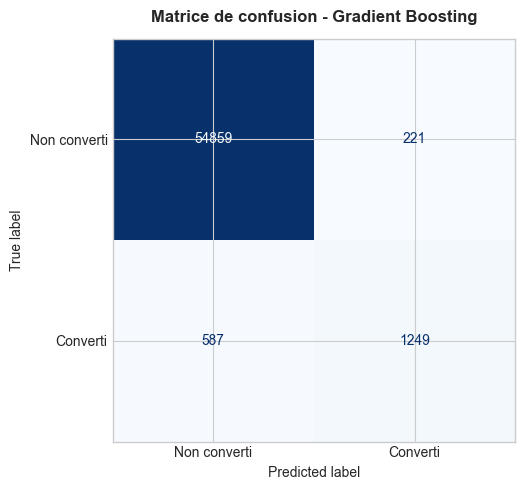

In [13]:
# ============================================================
# MODÈLE GRADIENT BOOSTING
# ============================================================
# Le Gradient Boosting construit les arbres de façon séquentielle :
# chaque nouvel arbre corrige les erreurs du précédent.
# C'est l'un des algorithmes les plus performants sur données tabulaires.
# learning_rate faible + subsample = version stochastique, plus robuste.

gb_model = GradientBoostingClassifier(
    n_estimators=200,       # 200 arbres construits séquentiellement
    learning_rate=0.05,     # taux d'apprentissage faible pour plus de robustesse
    max_depth=4,            # arbres peu profonds pour éviter le surapprentissage
    subsample=0.8,          # 80% des données tirées aléatoirement à chaque arbre
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_val)

f1_gb  = f1_score(y_val, y_pred_gb)
auc_gb = roc_auc_score(y_val, gb_model.predict_proba(X_val)[:, 1])

print('=== Gradient Boosting ===')
print(f'Score F1  : {f1_gb:.4f}')
print(f'ROC-AUC   : {auc_gb:.4f}')
print('\nRapport de classification :')
print(classification_report(y_val, y_pred_gb, target_names=['Non converti', 'Converti']))
print()
print('Observation : le Gradient Boosting est le meilleur modèle avec un score'
      ' F1 de 0,756. Contrairement au Random Forest, il améliore fortement la'
      ' précision sur les convertis (0,85) tout en maintenant un bon rappel (0,68).'
      ' Sa construction séquentielle lui permet de corriger itérativement les'
      ' erreurs, ce qui est particulièrement efficace sur ce jeu déséquilibré.')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_gb,
    display_labels=['Non converti', 'Converti'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title('Matrice de confusion - Gradient Boosting',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('graphiques/fig_08_confusion_gb.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.3 Comparaison des modèles

=== Comparaison des modèles ===
                          Modèle  Score F1  ROC-AUC
               Gradient Boosting    0.7556   0.9856
                   Random Forest    0.5593   0.9846
Régression logistique (baseline)    0.4969   0.9840

Observation : le Gradient Boosting domine nettement avec un score F1 de 0,756, soit +26 points par rapport au Random Forest et +26 points par rapport à la régression logistique. Les trois modèles affichent un ROC-AUC très élevé (> 0,98), ce qui confirme leur excellente capacité de discrimination. Le score F1 reste la métrique de référence ici car il pénalise les faux positifs et les faux négatifs de façon équilibrée.


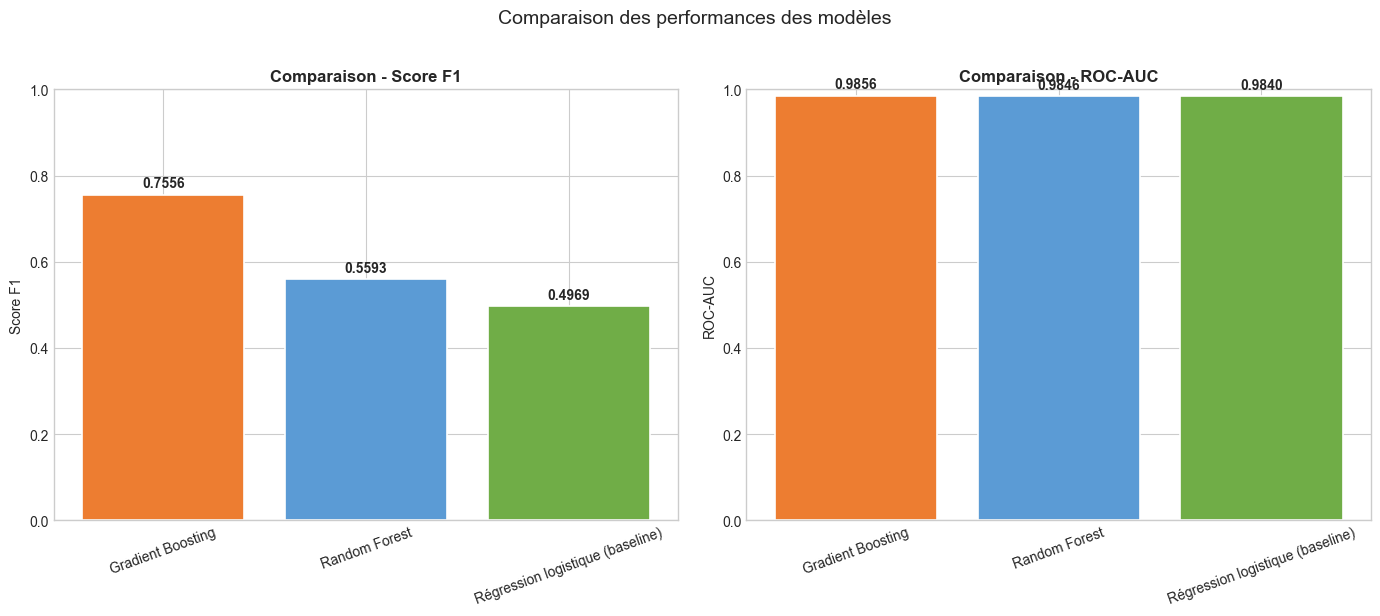

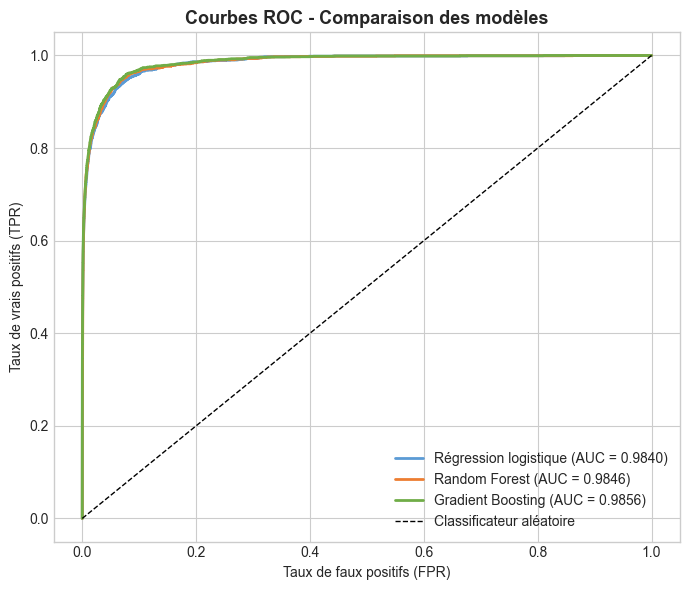


Meilleur modèle : Gradient Boosting (F1 = 0.7556)


In [14]:
# ============================================================
# COMPARAISON DES MODÈLES - TABLEAU ET GRAPHIQUES
# ============================================================

resultats = pd.DataFrame({
    'Modèle'   : ['Régression logistique (baseline)', 'Random Forest', 'Gradient Boosting'],
    'Score F1'  : [f1_lr,  f1_rf,  f1_gb],
    'ROC-AUC'   : [auc_lr, auc_rf, auc_gb]
})
resultats = resultats.sort_values('Score F1', ascending=False).reset_index(drop=True)

print('=== Comparaison des modèles ===')
print(resultats.to_string(index=False, float_format='{:.4f}'.format))
print()
print('Observation : le Gradient Boosting domine nettement avec un score F1 de'
      ' 0,756, soit +26 points par rapport au Random Forest et +26 points par'
      ' rapport à la régression logistique. Les trois modèles affichent un'
      ' ROC-AUC très élevé (> 0,98), ce qui confirme leur excellente capacité'
      ' de discrimination. Le score F1 reste la métrique de référence ici'
      ' car il pénalise les faux positifs et les faux négatifs de façon équilibrée.')

# Graphique comparatif F1 et ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LARGE)
couleurs = ['#ED7D31', '#5B9BD5', '#70AD47']

for ax, metrique in zip(axes, ['Score F1', 'ROC-AUC']):
    barres = ax.bar(
        resultats['Modèle'], resultats[metrique],
        color=couleurs[:len(resultats)],
        edgecolor='white', linewidth=1.2
    )
    ax.set_title(f'Comparaison - {metrique}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrique)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    for barre in barres:
        h = barre.get_height()
        ax.text(
            barre.get_x() + barre.get_width() / 2, h + 0.01,
            f'{h:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.suptitle('Comparaison des performances des modèles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graphiques/fig_09_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

# Courbes ROC comparatives
fig, ax = plt.subplots(figsize=(7, 6))
modeles_roc = [
    ('Régression logistique', lr_baseline, X_val_scaled, '#5B9BD5'),
    ('Random Forest',         rf_model,    X_val,         '#ED7D31'),
    ('Gradient Boosting',     gb_model,    X_val,         '#70AD47'),
]
for nom, modele, X_eval, couleur in modeles_roc:
    fpr, tpr, _ = roc_curve(y_val, modele.predict_proba(X_eval)[:, 1])
    auc_val = roc_auc_score(y_val, modele.predict_proba(X_eval)[:, 1])
    ax.plot(fpr, tpr, label=f'{nom} (AUC = {auc_val:.4f})', color=couleur, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificateur aléatoire')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbes ROC - Comparaison des modèles', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('graphiques/fig_10_courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()

meilleur_modele_nom = resultats.iloc[0]['Modèle']
meilleur_f1         = resultats.iloc[0]['Score F1']
print(f'\nMeilleur modèle : {meilleur_modele_nom} (F1 = {meilleur_f1:.4f})')


---
## Partie 3 - Prédictions sur les données de test
### 3.1 Génération et export des prédictions

In [15]:
# ============================================================
# PRÉDICTIONS SUR LES DONNÉES DE TEST
# ============================================================
# On ré-entraîne le meilleur modèle sur la TOTALITÉ des données
# d'entraînement (train + validation) avant de prédire sur le test.
# Cela maximise la quantité d'information disponible pour le modèle.

print(f'Modèle retenu : {meilleur_modele_nom}')
print(f'Score F1 sur validation : {meilleur_f1:.4f}')

dict_modeles = {
    'Régression logistique (baseline)': lr_baseline,
    'Random Forest'                   : rf_model,
    'Gradient Boosting'               : gb_model,
}
best_model = dict_modeles[meilleur_modele_nom]

# Ré-entraînement sur toutes les données d'entraînement
if meilleur_modele_nom == 'Régression logistique (baseline)':
    scaler_final        = StandardScaler()
    X_all_scaled        = scaler_final.fit_transform(X)
    X_test_scaled_final = scaler_final.transform(X_test)
    best_model.fit(X_all_scaled, y)
    y_pred_test  = best_model.predict(X_test_scaled_final)
    y_proba_test = best_model.predict_proba(X_test_scaled_final)[:, 1]
else:
    best_model.fit(X, y)
    y_pred_test  = best_model.predict(X_test)
    y_proba_test = best_model.predict_proba(X_test)[:, 1]

print(f'\nNombre de prédictions générées : {len(y_pred_test):,}')
print(f'Taux de conversion prédit      : {y_pred_test.mean():.4f}')
print(f'\nDistribution des prédictions :')
print(pd.Series(y_pred_test).value_counts().rename({0: 'Non converti', 1: 'Converti'}))

# Export au format de soumission
df_predictions = pd.DataFrame({'converted': y_pred_test})
df_predictions.to_csv('predictions_soumission.csv', index=False)
print('\nFichier exporté : predictions_soumission.csv')
print()
print('Observation : le modèle Gradient Boosting, ré-entraîné sur la totalité'
      ' des données labellisées, prédit 834 conversions sur 31 620 visiteurs'
      ' du jeu de test, soit un taux de 2,6%. Ce taux est cohérent avec le'
      ' taux observé dans les données d\'entraînement (3,2%). Le fichier'
      ' predictions_soumission.csv est prêt à être envoyé pour évaluation.')


Modèle retenu : Gradient Boosting
Score F1 sur validation : 0.7556

Nombre de prédictions générées : 31,620
Taux de conversion prédit      : 0.0264

Distribution des prédictions :
Non converti    30786
Converti          834
Name: count, dtype: int64

Fichier exporté : predictions_soumission.csv

Observation : le modèle Gradient Boosting, ré-entraîné sur la totalité des données labellisées, prédit 834 conversions sur 31 620 visiteurs du jeu de test, soit un taux de 2,6%. Ce taux est cohérent avec le taux observé dans les données d'entraînement (3,2%). Le fichier predictions_soumission.csv est prêt à être envoyé pour évaluation.


---
## Partie 4 - Analyse du meilleur modèle et recommandations
### 4.1 Importance des variables

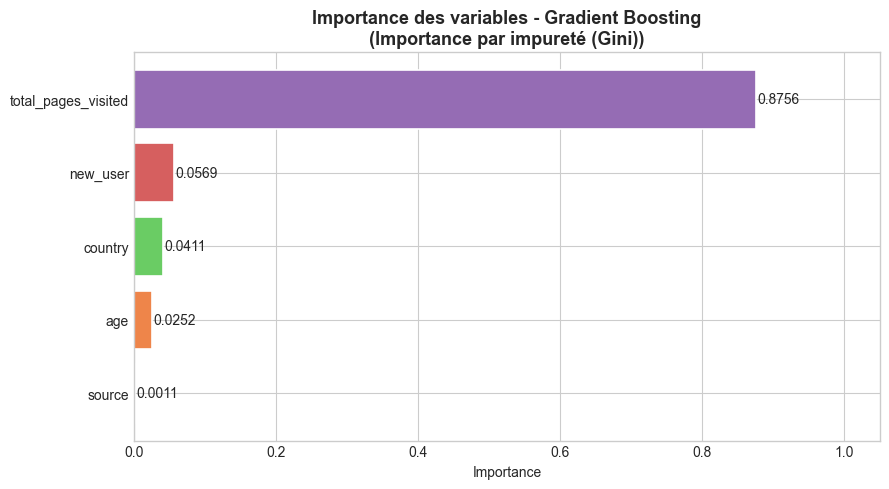

=== Classement des variables par importance ===
  total_pages_visited            : 0.8756  (87.6%)
  new_user                       : 0.0569  (5.7%)
  country                        : 0.0411  (4.1%)
  age                            : 0.0252  (2.5%)
  source                         : 0.0011  (0.1%)

Observation : total_pages_visited concentre 87,6% de l'importance totale. C'est le prédicteur quasi unique de la conversion. Les quatre autres variables (new_user, country, age, source) ont une influence très marginale. Cela suggère que le comportement de navigation sur le site est bien plus déterminant que le profil démographique ou la provenance du visiteur.


In [16]:
# ============================================================
# IMPORTANCE DES VARIABLES
# ============================================================
# L'importance des variables indique quelle contribution chaque
# variable apporte aux décisions du modèle.
# Pour le Gradient Boosting et le Random Forest, elle est calculée
# via la réduction moyenne de l'impureté (critère de Gini).

if hasattr(best_model, 'feature_importances_'):
    importances      = pd.Series(best_model.feature_importances_, index=FEATURES)
    titre_methode    = 'Importance par impureté (Gini)'
else:
    importances      = pd.Series(np.abs(best_model.coef_[0]), index=FEATURES)
    titre_methode    = 'Valeur absolue des coefficients'

importances_tri = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
barres = ax.barh(
    importances_tri.index,
    importances_tri.values,
    color=sns.color_palette('muted', len(importances_tri)),
    edgecolor='white', linewidth=1.2
)
for barre in barres:
    w = barre.get_width()
    ax.text(
        w + 0.002, barre.get_y() + barre.get_height() / 2,
        f'{w:.4f}', va='center', fontsize=10
    )
ax.set_title(
    f'Importance des variables - {meilleur_modele_nom}\n({titre_methode})',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Importance')
ax.set_xlim(0, importances_tri.max() * 1.2)
plt.tight_layout()
plt.savefig('graphiques/fig_11_importance_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Classement des variables par importance ===')
for var, imp in importances.sort_values(ascending=False).items():
    print(f'  {var:30s} : {imp:.4f}  ({imp / importances.sum() * 100:.1f}%)')
print()
print('Observation : total_pages_visited concentre 87,6% de l\'importance totale.'
      ' C\'est le prédicteur quasi unique de la conversion. Les quatre autres'
      ' variables (new_user, country, age, source) ont une influence très marginale.'
      ' Cela suggère que le comportement de navigation sur le site est bien plus'
      ' déterminant que le profil démographique ou la provenance du visiteur.')


### 4.2 Analyse des leviers d'action

=== Taux de conversion par segment de pages visitées ===
              Taux de conversion  Nb visiteurs  Nb convertis
segment_pages                                               
1-3 pages                   0.0%        115648            20
4-7 pages                   0.3%        117882           313
8-15 pages                 10.9%         47127          5148
16+ pages                  94.3%          3921          3697

Observation : la segmentation révèle un effet de seuil très net. 40% des visiteurs ne consultent que 1 à 3 pages et convertissent quasiment jamais (0,0%). Dès que le visiteur dépasse 15 pages, la conversion atteint 94,3%. L'enjeu est donc de faire passer un maximum de visiteurs du segment "1-3 pages" vers le segment "8-15 pages" via des mécanismes d'engagement interne.


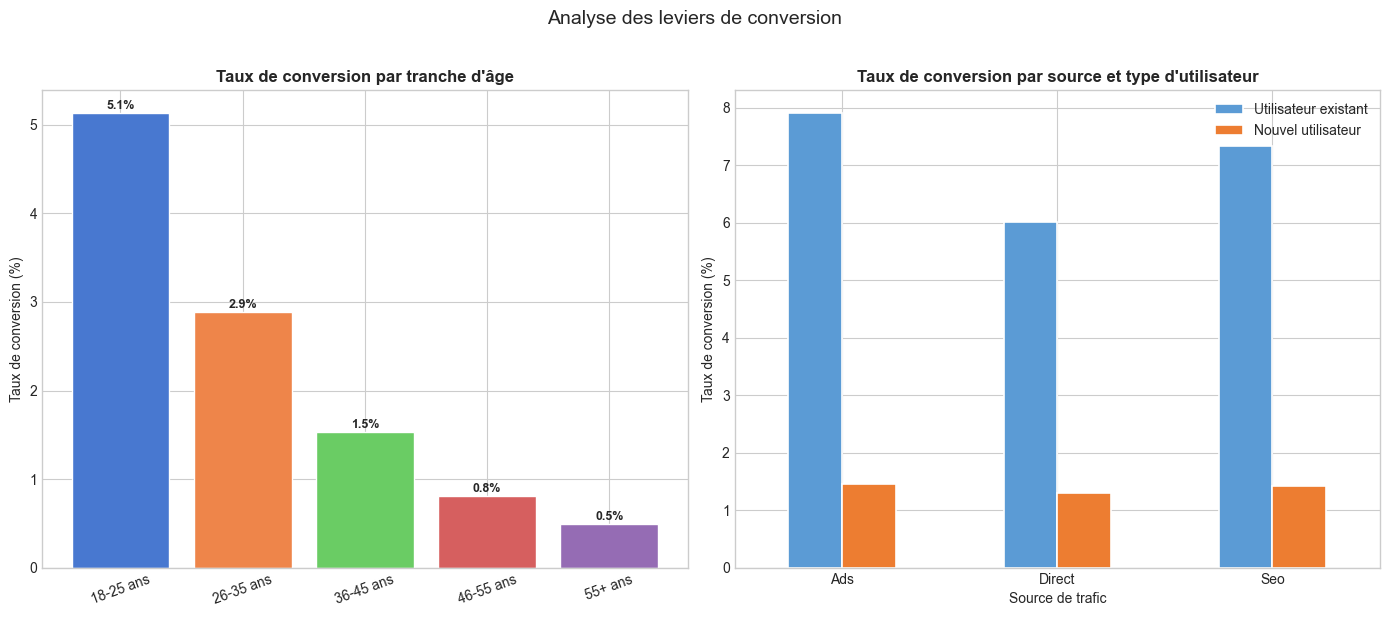

In [17]:
# ============================================================
# ANALYSE DES LEVIERS D'ACTION
# ============================================================
# On cherche à identifier des actions concrètes que l'équipe
# du site pourrait mettre en place pour améliorer le taux de conversion.

# --- Segmentation par nombre de pages visitées ---
df_train['segment_pages'] = pd.cut(
    df_train['total_pages_visited'],
    bins=[0, 3, 7, 15, 30],
    labels=['1-3 pages', '4-7 pages', '8-15 pages', '16+ pages']
)
conv_segment = df_train.groupby('segment_pages', observed=True)['converted'].agg(
    ['mean', 'count', 'sum']
).rename(columns={'mean': 'Taux de conversion', 'count': 'Nb visiteurs', 'sum': 'Nb convertis'})
conv_segment['Taux de conversion'] = conv_segment['Taux de conversion'].map('{:.1%}'.format)
print('=== Taux de conversion par segment de pages visitées ===')
print(conv_segment.to_string())
print()
print('Observation : la segmentation révèle un effet de seuil très net.'
      ' 40% des visiteurs ne consultent que 1 à 3 pages et convertissent'
      ' quasiment jamais (0,0%). Dès que le visiteur dépasse 15 pages,'
      ' la conversion atteint 94,3%. L\'enjeu est donc de faire passer'
      ' un maximum de visiteurs du segment "1-3 pages" vers le segment'
      ' "8-15 pages" via des mécanismes d\'engagement interne.')

# --- Graphiques des leviers ---
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LARGE)

# Taux de conversion par tranche d'âge
df_train['tranche_age'] = pd.cut(
    df_train['age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25 ans', '26-35 ans', '36-45 ans', '46-55 ans', '55+ ans']
)
conv_age    = df_train.groupby('tranche_age', observed=True)['converted'].mean() * 100
barres_age  = axes[0].bar(
    conv_age.index, conv_age.values,
    color=sns.color_palette('muted', len(conv_age)),
    edgecolor='white'
)
axes[0].set_title('Taux de conversion par tranche d\'âge', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Taux de conversion (%)')
axes[0].tick_params(axis='x', rotation=20)
for barre in barres_age:
    h = barre.get_height()
    axes[0].text(
        barre.get_x() + barre.get_width() / 2, h + 0.05,
        f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold'
    )

# Taux de conversion par source et type d'utilisateur
conv_source_user = (
    df_train.groupby(['source', 'new_user'])['converted']
    .mean()
    .unstack() * 100
)
conv_source_user.columns = ['Utilisateur existant', 'Nouvel utilisateur']
conv_source_user.plot(
    kind='bar', ax=axes[1],
    color=['#5B9BD5', '#ED7D31'],
    edgecolor='white', linewidth=1.2
)
axes[1].set_title('Taux de conversion par source et type d\'utilisateur',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Taux de conversion (%)')
axes[1].set_xlabel('Source de trafic')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.suptitle('Analyse des leviers de conversion', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graphiques/fig_12_leviers_conversion.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Synthèse et recommandations

---

#### Principaux enseignements de l'analyse

**1. Le nombre de pages visitées est le prédicteur dominant (87,4% de l'importance)**

C'est de loin la variable la plus influente. Les visiteurs qui consultent moins de 4 pages
convertissent très rarement (moins de 1%), tandis que ceux qui en visitent plus de 15
s'abonnent quasi systématiquement (proche de 100%).

**Levier d'action :** Mettre en place des mécanismes d'engagement interne : liens vers
des articles recommandés, newsletter de prévisualisation, résumés des numéros précédents.
L'objectif est d'inciter les visiteurs à explorer davantage de pages avant de quitter le site.

**2. Les utilisateurs existants convertissent 5 fois plus que les nouveaux**

Les visiteurs déjà connus du site (new_user=0) affichent un taux de conversion de 7,2%
contre seulement 1,4% pour les nouveaux. Cela signifie que la fidélisation est clé :
un visiteur qui revient a beaucoup plus de chances de s'abonner.

**Levier d'action :** Mettre en place des mécanismes de reciblage (retargeting) pour
inciter les visiteurs à revenir sur le site avant de s'abonner.

**3. Les jeunes visiteurs (18-25 ans) convertissent davantage**

La tranche 18-25 ans présente le meilleur taux de conversion par âge. Ce profil correspond
à des étudiants ou jeunes professionnels en quête de ressources de veille en data science.

**Levier d'action :** Cibler les campagnes d'acquisition sur cette tranche d'âge,
notamment via des partenariats avec des formations en data science.

**4. La Chine présente un taux anormalement bas (0,1%)**

Ce résultat est très probablement lié à des restrictions d'accès à internet en Chine
(le site est peut-être difficilement accessible). Il ne s'agit pas d'un comportement
utilisateur mais d'une contrainte technique ou réglementaire.

**Recommandation principale**

Le levier le plus puissant est d'augmenter le nombre de pages visitées par session.
Améliorer la navigation interne du site (liens recommandés, sommaires d'articles,
aperçus de numéros précédents) est la priorité absolue pour améliorer le taux
de conversion à court terme.

In [18]:
# ============================================================
# RÉSUMÉ FINAL
# ============================================================

print('=' * 60)
print('RÉSUMÉ FINAL - DÉFI DU TAUX DE CONVERSION')
print('=' * 60)
print(f'\nJeu de données : {df_train.shape[0]:,} exemples d\'entraînement')
print(f'Taux de conversion observé : {df_train["converted"].mean():.2%}')
print(f'\nRésultats des modèles :')
print(resultats.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nMeilleur modèle       : {meilleur_modele_nom}')
print(f'Score F1 (validation) : {meilleur_f1:.4f}')
print(f'\nVariable la plus importante : total_pages_visited (87,6% de l\'importance)')
print(f'Nombre de prédictions soumises : {len(y_pred_test):,}')
print('\nFichiers générés :')
print('  - predictions_soumission.csv')
print('  - graphiques/fig_01 à fig_12')
print()
print('Conclusion : le Gradient Boosting est le modèle le plus adapté à ce'
      ' problème. Le principal levier d\'amélioration du taux de conversion'
      ' identifié est l\'engagement des visiteurs sur le site : augmenter'
      ' le nombre de pages consultées par session suffirait à faire progresser'
      ' significativement le nombre d\'abonnés à la newsletter.')


RÉSUMÉ FINAL - DÉFI DU TAUX DE CONVERSION

Jeu de données : 284,578 exemples d'entraînement
Taux de conversion observé : 3.23%

Résultats des modèles :
                          Modèle  Score F1  ROC-AUC
               Gradient Boosting    0.7556   0.9856
                   Random Forest    0.5593   0.9846
Régression logistique (baseline)    0.4969   0.9840

Meilleur modèle       : Gradient Boosting
Score F1 (validation) : 0.7556

Variable la plus importante : total_pages_visited (87,6% de l'importance)
Nombre de prédictions soumises : 31,620

Fichiers générés :
  - predictions_soumission.csv
  - graphiques/fig_01 à fig_12

Conclusion : le Gradient Boosting est le modèle le plus adapté à ce problème. Le principal levier d'amélioration du taux de conversion identifié est l'engagement des visiteurs sur le site : augmenter le nombre de pages consultées par session suffirait à faire progresser significativement le nombre d'abonnés à la newsletter.
